# Analyse des Retards de Vols ✈️

## Contexte et Objectifs

Des millions de personnes voyagent en avion chaque jour, et les retards au départ peuvent s'avérer particulièrement frustrants. Ce projet propose d'analyser des données réelles de vols pour répondre à la question suivante :

> **Le jour de la semaine influence-t-il la probabilité d'avoir un vol retardé ?**

Nous allons travailler avec un échantillon de vols domestiques au départ de l'aéroport Hartsfield-Jackson d'Atlanta (ATL), le plus fréquenté au monde, pour l'année 2023.

### Plan du projet
1. **Chargement des données** – importer et explorer le jeu de données
2. **Extraction des colonnes pertinentes** – isoler les heures de départ
3. **Conversion des types** – transformer les chaînes de caractères en objets datetime
4. **Calcul des retards** – calculer la durée de retard pour chaque vol
5. **Identification des vols en retard** – définir un seuil de retard
6. **Extraction du jour de la semaine** – associer chaque vol à un jour
7. **Calcul du pourcentage de retard par jour** – agrégation statistique
8. **Visualisation** – produire un graphique clair et interprétable

---
## Étape 1 – Chargement des données


On commence par importer les bibliothèques nécessaires (`pandas` pour la manipulation des données, `matplotlib` pour la visualisation) puis on charge le fichier CSV contenant les vols.

La méthode `convert_dtypes()` est utilisée pour laisser pandas inférer automatiquement les types les plus adaptés pour chaque colonne (par exemple, `string` plutôt que `object` pour les textes).

In [ ]:
# Pour Google Colab uniquement :
# Décommentez et exécutez le code ci-dessous. Une boîte de dialogue s'ouvrira pour uploader le fichier.
# Uploadez 'flights.csv'.

# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

flights = pd.read_csv('flights.csv')
flights = flights.convert_dtypes()
flights

,scheduled,actual,carrier,flight,tailnum,origin,dest,air_time,distance
0,"04/29/2023, 16:35","04/29/2023, 17:01",WN,1079,N230WN,ATL,HOU,110,696
1,"07/02/2023, 15:10","07/02/2023, 15:05",DL,355,N953AT,ATL,GPT,54,352
2,"12/25/2023, 10:55","12/25/2023, 10:53",WN,291,N413WN,ATL,RDU,57,356
3,"09/01/2023, 12:50","09/01/2023, 12:48",DL,1132,N947DZ,ATL,TYS,28,152
4,"12/14/2023, 07:05","12/14/2023, 07:02",DL,40,N332DN,ATL,BOS,121,946
...,...,...,...,...,...,...,...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17",WN,13,N400WN,ATL,MCO,63,404
4996,"04/09/2023, 19:50","04/09/2023, 19:58",OH,1320,N567NN,ATL,CLT,42,226
4997,"12/14/2023, 13:20","12/14/2023, 13:16",DL,695,N363NB,ATL,DAL,103,721
4998,"12/06/2023, 13:05","12/06/2023, 13:01",DL,911,N992AT,ATL,GSO,56,306




Le DataFrame `flights` contient **5 000 vols** et **9 colonnes** :

| Colonne | Description |
|---|---|
| `scheduled` | Heure de départ prévue |
| `actual` | Heure de départ réelle |
| `carrier` | Code de la compagnie aérienne |
| `flight` | Numéro de vol |
| `tailnum` | Immatriculation de l'avion |
| `origin` | Aéroport de départ (toujours ATL ici) |
| `dest` | Aéroport de destination |
| `air_time` | Durée de vol en minutes |
| `distance` | Distance parcourue en miles |

Les colonnes `scheduled` et `actual` sont stockées comme des **chaînes de caractères** (type `string`). Pour calculer un écart de temps, il faudra les convertir en objets **datetime**.

---
## Étape 2 – Extraction des colonnes de départ


On crée un nouveau DataFrame `departures` contenant uniquement les colonnes `scheduled` (heure prévue) et `actual` (heure réelle). Cela simplifie notre travail pour la suite de l'analyse.

In [2]:
departures = flights[['scheduled', 'actual']]
departures

,scheduled,actual
0,"04/29/2023, 16:35","04/29/2023, 17:01"
1,"07/02/2023, 15:10","07/02/2023, 15:05"
2,"12/25/2023, 10:55","12/25/2023, 10:53"
3,"09/01/2023, 12:50","09/01/2023, 12:48"
4,"12/14/2023, 07:05","12/14/2023, 07:02"
...,...,...
4995,"11/15/2023, 14:20","11/15/2023, 14:17"
4996,"04/09/2023, 19:50","04/09/2023, 19:58"
4997,"12/14/2023, 13:20","12/14/2023, 13:16"
4998,"12/06/2023, 13:05","12/06/2023, 13:01"




On isole les deux colonnes d'intérêt. Chaque ligne représente un vol avec :
- l'heure à laquelle il **aurait dû** partir (`scheduled`)
- l'heure à laquelle il est **réellement** parti (`actual`)

On voit par exemple que le premier vol a décollé à 17h01 alors qu'il était prévu à 16h35 → **retard de 26 minutes**.

---
## Étape 3 – Vérification des types de données


Avant de faire des calculs, il est crucial de vérifier les types des colonnes. On utilise la méthode `info()` qui affiche un résumé du DataFrame.

In [3]:
departures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   scheduled  5000 non-null   string
 1   actual     5000 non-null   string
dtypes: string(2)
memory usage: 78.3 KB




La sortie confirme que les deux colonnes sont de type **`string`**. Les chaînes de caractères ne permettent pas de faire des soustractions arithmétiques pour calculer des durées. Il faut donc les convertir en objets **`datetime`** dans l'étape suivante.

---
## Étape 4 – Conversion en datetime


Pandas propose la fonction `pd.to_datetime()` qui analyse automatiquement une chaîne de caractères représentant une date/heure et la convertit en objet `datetime64[ns]`. Ce type permet toutes les opérations arithmétiques sur les dates et heures.

On applique cette conversion aux deux colonnes `scheduled` et `actual`.

In [4]:
departures['scheduled'] = pd.to_datetime(departures['scheduled'])
departures['actual'] = pd.to_datetime(departures['actual'])
departures

C:\Users\ali store\AppData\Local\Temp\ipykernel_24556\2491197855.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['scheduled'] = pd.to_datetime(departures['scheduled'])
C:\Users\ali store\AppData\Local\Temp\ipykernel_24556\2491197855.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['actual'] = pd.to_datetime(departures['actual'])


,scheduled,actual
0,2023-04-29 16:35:00,2023-04-29 17:01:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00
...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00


### 📌 Interprétation

Les dates ont été reformatées au format ISO standard `YYYY-MM-DD HH:MM:SS`. Ce changement de format visuel traduit une transformation profonde : les valeurs ne sont plus de simples textes, mais des **objets temporels** sur lesquels on peut désormais appliquer des opérations mathématiques.

On vérifie le nouveau type avec `info()` :

In [5]:
departures.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   scheduled  5000 non-null   datetime64[ns]
 1   actual     5000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 78.3 KB


Les deux colonnes sont maintenant de type **`datetime64[ns]`**. Nous sommes prêts à calculer les retards.

---
## Étape 5 – Calcul du retard


Le retard de chaque vol est calculé par la formule :

> `retard = heure_réelle − heure_prévue`

On utilise la méthode `eval()` de pandas pour effectuer cette opération de manière concise. Le résultat est un objet de type `Timedelta` (durée), stocké dans une nouvelle colonne `delay`.

In [6]:
departures['delay'] = departures.eval('actual - scheduled')
departures

C:\Users\ali store\AppData\Local\Temp\ipykernel_24556\1876375920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['delay'] = departures.eval('actual - scheduled')


,scheduled,actual,delay
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00
...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00


### 📌 Interprétation

La colonne `delay` contient maintenant la durée de retard pour chaque vol :

- Une valeur **positive** (ex : `0 days 00:26:00`) indique un **retard** : le vol est parti après l'heure prévue.
- Une valeur **négative** (ex : `-1 days +23:55:00`) indique une **avance** : le vol est parti **avant** l'heure prévue. La notation peut sembler étrange car pandas représente `-5 minutes` comme `-1 days + 23:55:00` (soit 24h - 5min).

Les deux premiers exemples illustrent parfaitement ces deux cas :
- Vol 0 : retard de **26 minutes**
- Vol 1 : avance de **5 minutes**

---
## Étape 6 – Identification des vols en retard


Dans l'industrie aérienne, un vol n'est officiellement considéré comme **en retard** que s'il décolle plus de **15 minutes** (soit 900 secondes) après son heure prévue. Les petits décalages de quelques minutes sont tolérés.

On utilise `.dt.total_seconds()` pour convertir chaque `Timedelta` en nombre total de secondes, puis on compare avec le seuil de 900 secondes. Le résultat est une colonne booléenne `is_late` (`True` = retard, `False` = à l'heure ou en avance).

In [7]:
departures['is_late'] = departures['delay'].dt.total_seconds() > 900
departures

C:\Users\ali store\AppData\Local\Temp\ipykernel_24556\1920595144.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['is_late'] = departures['delay'].dt.total_seconds() > 900


,scheduled,actual,delay,is_late
0,2023-04-29 16:35:00,2023-04-29 17:01:00,0 days 00:26:00,True
1,2023-07-02 15:10:00,2023-07-02 15:05:00,-1 days +23:55:00,False
2,2023-12-25 10:55:00,2023-12-25 10:53:00,-1 days +23:58:00,False
3,2023-09-01 12:50:00,2023-09-01 12:48:00,-1 days +23:58:00,False
4,2023-12-14 07:05:00,2023-12-14 07:02:00,-1 days +23:57:00,False
...,...,...,...,...
4995,2023-11-15 14:20:00,2023-11-15 14:17:00,-1 days +23:57:00,False
4996,2023-04-09 19:50:00,2023-04-09 19:58:00,0 days 00:08:00,False
4997,2023-12-14 13:20:00,2023-12-14 13:16:00,-1 days +23:56:00,False
4998,2023-12-06 13:05:00,2023-12-06 13:01:00,-1 days +23:56:00,False




La colonne `is_late` est de type booléen (`True`/`False`). Ce format binaire est très pratique pour les calculs statistiques : en particulier, la **moyenne** d'une colonne booléenne donne directement la **proportion** de valeurs `True`.

Par exemple :
- Le vol 0 (`+26 min`) → `True` : il est en retard ✗
- Le vol 1 (`-5 min`) → `False` : il est à l'heure ✓
- Le vol 4996 (`+8 min`) → `False` : moins de 15 min de retard, considéré à l'heure ✓

---
## Étape 7 – Extraction du jour de la semaine


Pour analyser l'impact du jour de la semaine, on extrait le nom abrégé du jour (Mon, Tue, Wed…) de la colonne `actual` grâce à la méthode `strftime('%a')`.

Le format `'%a'` retourne l'abréviation du jour en anglais (3 lettres) selon les paramètres régionaux du système. Le résultat est stocké dans une nouvelle colonne `day_name`.

> On sauvegarde également un point de contrôle dans un fichier TSV pour ne pas perdre le travail.

In [8]:
departures['day_name'] = departures['actual'].dt.strftime('%a')
departures
departures.to_csv('departures-check-point.tsv', index=False, sep='\t')

C:\Users\ali store\AppData\Local\Temp\ipykernel_24556\2676817665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  departures['day_name'] = departures['actual'].dt.strftime('%a')




Chaque vol est maintenant associé à un jour de la semaine. Cette information est indispensable pour l'agrégation par jour dans l'étape suivante. On dispose maintenant de toutes les colonnes nécessaires à l'analyse finale.

---
## Étape 8 – Pourcentage de vols en retard par jour

On regroupe le DataFrame par `day_name` avec `groupby()`, puis on calcule la **moyenne** de `is_late` pour chaque groupe. Puisque `is_late` est une colonne de booléens (0 ou 1), sa moyenne donne directement la **proportion** de vols en retard. On multiplie par 100 pour obtenir un **pourcentage**.

In [9]:
proportion_delayed = departures.groupby('day_name')['is_late'].mean()
percent_delayed = proportion_delayed * 100
percent_delayed

day_name
Fri    22.593583
Mon    20.185923
Sat    18.558282
Sun    23.376623
Thu    20.939597
Tue    15.419847
Wed    16.691285
Name: is_late, dtype: float64



Les résultats sont triés par ordre **alphabétique** du jour (Fri, Mon, Sat…). On observe déjà des différences notables :

| Jour | % de vols retardés |
|---|---|
| Vendredi (Fri) | ~22,6 % |
| Lundi (Mon) | ~20,2 % |
| Samedi (Sat) | ~18,6 % |
| **Dimanche (Sun)** | **~23,4 %** ← maximum |
| Jeudi (Thu) | ~20,9 % |
| **Mardi (Tue)** | **~15,4 %** ← minimum |
| Mercredi (Wed) | ~16,7 % |

Le dimanche est le jour avec le plus de retards et le mardi celui avec le moins. La plage de variation est d'environ **8 points de pourcentage**, ce qui est significatif.

---
## Étape 9 – Réorganisation des données

Pour une lecture plus naturelle et intuitive du graphique, on réordonne les données dans l'ordre chronologique des jours (Dim → Sam) en utilisant la méthode `reindex()`.

In [10]:
new_index_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
percent_delayed = percent_delayed.reindex(new_index_order)
percent_delayed

day_name
Sun    23.376623
Mon    20.185923
Tue    15.419847
Wed    16.691285
Thu    20.939597
Fri    22.593583
Sat    18.558282
Name: is_late, dtype: float64



Les données sont maintenant dans l'ordre naturel de la semaine (dimanche en premier, selon la convention américaine). On peut clairement voir une **tendance en U** : les taux de retard sont plus élevés en début et en fin de semaine, et plus faibles en milieu de semaine (mardi et mercredi).

---
## Étape 10 – Visualisation des retards par jour

On trace un graphique en barres (`bar chart`) pour visualiser le pourcentage de vols retardés pour chaque jour de la semaine. L'axe Y est labellisé pour indiquer l'unité (pourcentage).

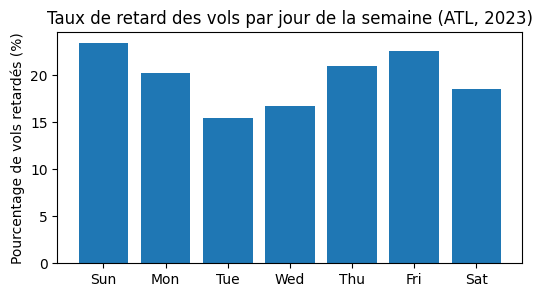

In [11]:
plt.figure(figsize=(6, 3))
plt.bar(percent_delayed.index, percent_delayed)
plt.ylabel('Pourcentage de vols retardés (%)')
plt.title('Taux de retard des vols par jour de la semaine (ATL, 2023)')
plt.show()

### 📌 Interprétation et Conclusions

Le graphique met en évidence plusieurs observations intéressantes :

1. **Le dimanche et le vendredi** sont les jours les plus « risqués » pour les retards (autour de 22-23 %). Ce sont des jours de forte demande liés aux voyages de loisirs (week-end) et aux retours de déplacements professionnels.

2. **Le mardi et le mercredi** sont les jours les plus « sûrs » (environ 15-17 %). Ces jours sont généralement moins fréquentés, avec moins de touristes et des opérations aériennes plus fluides.

3. On observe une **forme de U** au cours de la semaine : les extrémités (week-end étendu) concentrent plus de retards que le milieu de semaine.

**Conseil pratique** : Si vous avez le choix de la date pour votre prochain vol, privilégiez le mardi ou le mercredi pour réduire le risque de retard !